<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week12/Day2/ExercisesXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Traffic Data Analysis - Student Exercise
# Inferential Statistics and Regression Analysis
**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with #TODO.

**Dataset Description:**
* Dom_Pax: Domestic Air Travel Passengers
* Int_Pax: International Air Travel Passengers
* Pax: Total Air Travel Passengers
* Dom_Flt: Number of Flights (Domestic)
* Int_Flt: Number of Flights (International)
* Flt: Number of Flights (Total)
* Dom_RPM: Revenue Passenger-miles (Domestic)

# 1. Setup and Data Loading

In [1]:
# Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
# Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# From scipy import stats
# From sklearn.model_selection import train_test_split
# From sklearn.linear_model import LinearRegression
# From sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# From sklearn.preprocessing import StandardScaler

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

# try:
#     # Your code to load the dataset:
#     df = # TODO: Complete this line
#     print("Dataset loaded successfully!")
#     print(f"Shape: {df.shape}")
# except FileNotFoundError:
#     print("Creating sample air traffic data...")
#     import numpy as np
#     import pandas as pd

# Create sample data
np.random.seed(42)
n_samples = 200

# Generate correlated data

# Flights represent the OFFER
dom_flights = np.random.normal(15000, 3000, n_samples)  # 12 - 18  mil
int_flights = np.random.normal(8000, 2000, n_samples)  # 6 - 10 mil

# Passengers represent DEMAND
# Passengers ≈ flights × average passengers per flight + noise
# There are usually more per int flight (that's why they use ~15 vs ~12 for domestic flights).
dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)


# erformance Column (Real Business)
# Dom_RPM (Revenue Passenger Miles) ) = how far passengers travel.
# dom_rpm = dom_pax × ~800 miles average
dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

# Ensure positive values
dom_flights = np.abs(dom_flights)
int_flights = np.abs(int_flights)
dom_pax = np.abs(dom_pax)
int_pax = np.abs(int_pax)
dom_rpm = np.abs(dom_rpm)

df = pd.DataFrame({
  'Dom_Flt': dom_flights.astype(int),
  'Int_Flt': int_flights.astype(int),
  'Flt': (dom_flights + int_flights).astype(int),
  'Dom_Pax': dom_pax.astype(int),
  'Int_Pax': int_pax.astype(int),
  'Pax': (dom_pax + int_pax).astype(int),
  'Dom_RPM': dom_rpm.astype(int)
    })

print("Sample data created successfully!")
print(f"Shape: {df.shape}")

Sample data created successfully!
Shape: (200, 7)


# 2. Exploratory Data Analysis

In [3]:
# Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
display(df.info())

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB


None


First 5 rows:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
0,16490,8715,25205,152866,176257,329123,124207802
1,14585,9121,23706,148316,136571,284888,112284645
2,16943,10166,27109,212190,156317,368508,172347465
3,19569,10107,29676,250224,127892,378116,213773981
4,14297,5244,19542,162835,82306,245142,131063749



Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [4]:
# Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
display(df.isnull().sum())  #no missing values

# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:


,0
Dom_Flt,0
Int_Flt,0
Flt,0
Dom_Pax,0
Int_Pax,0
Pax,0
Dom_RPM,0


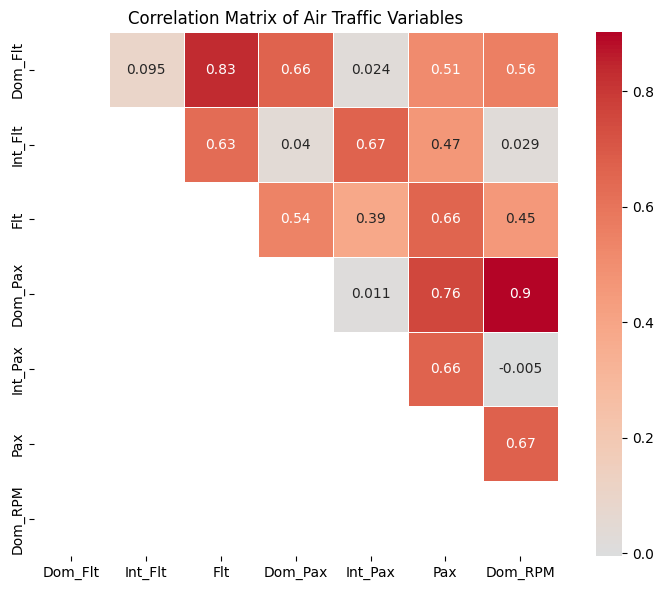

Strongest correlations:

Strongest positive correlations:
Dom_Pax  Dom_RPM    0.902
Dom_Flt  Flt        0.835
Dom_Pax  Pax        0.756
Dom_RPM  Pax        0.672
Int_Flt  Int_Pax    0.666
dtype: float64


In [5]:
# Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(8, 6))

# Calculate correlation matrix:
correlation_matrix = df.corr().round(3)
mask = np.tril(np.ones_like(correlation_matrix, dtype=bool))  # mask to avoid lower triangle

# Create heatmap: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
    )

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)

print("Strongest correlations:")
# Remove diagonal (self-correlation)
corr_matrix_no_diag = correlation_matrix.copy()
np.fill_diagonal(corr_matrix_no_diag.values, 0)

# Unstack and sort
sorted_corr = corr_matrix_no_diag.unstack().sort_values(ascending=False)

# Remove duplicate pairs (A-B and B-A)
sorted_corr = sorted_corr[sorted_corr.index.get_level_values(0) < sorted_corr.index.get_level_values(1)]

print("\nStrongest positive correlations:")
print(sorted_corr.head(5))
# Strong correlations are not "coincidence," they are fictitious mathematical constructs.
# It's not real data; if it were, redundant variables would be eliminated before modeling.

# Strongest positive correlations:
# Dom_Pax  Dom_RPM    0.902
# Dom_Flt  Flt        0.835
# Dom_Pax  Pax        0.756
# Dom_RPM  Pax        0.672
# Int_Flt  Int_Pax    0.666


# There are NO strong negative correlations

# 3. Hypothesis Testing

In [6]:
from re import S
# Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:

# Complete this line using stats.ttest_ind()
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'] , equal_var=False)  # Welch's t-test does NOT assume equality of variances

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Print the mean values for both groups
mean_dom = df['Dom_Pax'].mean()
mean_int = df['Int_Pax'].mean()

print(f"Mean Domestic Passengers: {mean_dom:.0f}")
print(f"Mean International Passengers: {mean_int:.0f}")

# Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p = {p_value:.6f} < {alpha})")
    print("There is a statistically significant difference between the averages of domestic and international passengers.")
else:
    # Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p = {p_value:.6f} >= {alpha})")
    print("There is no statistically significant difference between the averages of domestic and international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p = 0.000000 < 0.05)
There is a statistically significant difference between the averages of domestic and international passengers.


In [7]:
#  Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
# Complete this line using stats.pearsonr()
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])


print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.3f}")
print(f"P-value: {p_value_corr:.6f}")

#  Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p {p_value_corr:.6f} < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # Add interpretation about positive/negative correlation
    #  Interpretation of correlation direction
    if correlation_coef > 0:
        print("The correlation is positive: as total flights increase, total passengers tend to increase as well.")
    else:
        print("The correlation is negative: as total flights increase, total passengers tend to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p {p_value_corr:.6f} >= {alpha})")
    print("There is no statistically significant evidence of a correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.659
P-value: 0.000000

Conclusion: Reject H0 (p 0.000000 < 0.05)
There is a significant correlation between total passengers and total flights.
The correlation is positive: as total flights increase, total passengers tend to increase as well.


# 4. Simple Linear Regression

In [8]:
# Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']] # Select the feature column (Total Flights)
y_simple = df['Pax'] # Select the target column (Total Passengers)

# Split the data:
# Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression() # Create LinearRegression instance
simple_model.fit(X_train_simple, y_train_simple)  # Fit the model using X_train_simple and y_train_simple

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)    # Predict on test data

# Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple) # Calculate R² score
mse_simple = mean_squared_error(y_test_simple, y_pred_simple) # Calculate MSE
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple) # Calculate MAE
rmse_simple = np.sqrt(mse_simple) # Calculate RMSE (square root of MSE)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


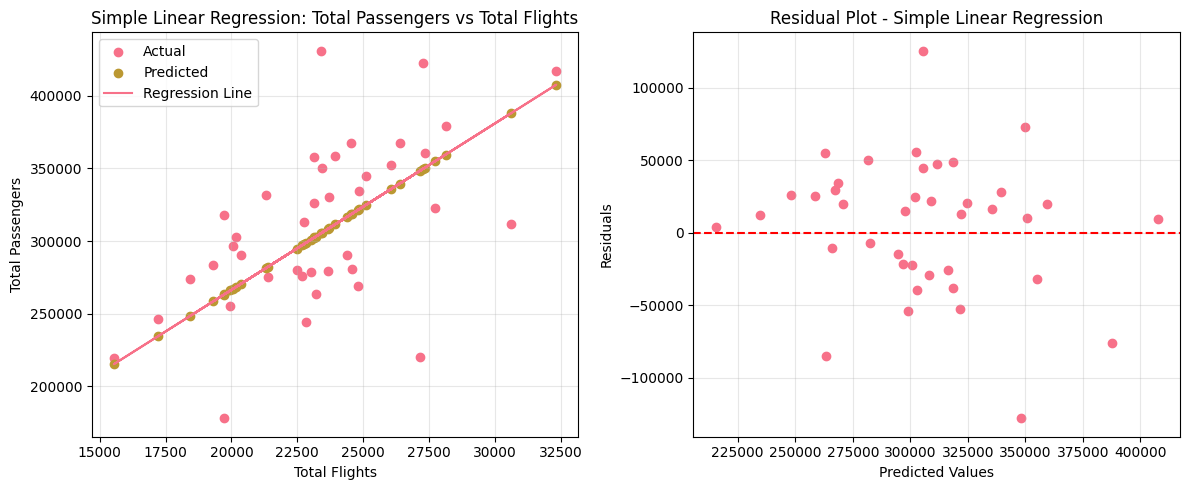

In [9]:
# Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
plt.scatter(X_test_simple, y_test_simple, label='Actual')  # actual
plt.scatter(X_test_simple, y_pred_simple, label='Predicted')  # predicted

X_sorted = np.sort(X_test_simple.values.reshape(-1, 1))
y_line = simple_model.predict(X_sorted)
plt.plot(X_sorted, y_line, label='Regression Line')   # plt.plot() for the line

plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple  # Calculate residuals

# Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Multiple Linear Regression

In [10]:
# Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']  # List of feature column names

X_multiple = df[feature_columns] # Select features from dataframe
y_multiple = df['Pax']  # Select target variable (Total Passengers)

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

# Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler() # Create StandardScaler instance
X_train_mult_scaled = scaler.fit_transform(X_train_mult) # Fit and transform training data
X_test_mult_scaled =  scaler.transform(X_test_mult) # Transform test data (don't fit again!)

# Create and train the multiple regression model
multiple_model = LinearRegression() # Create LinearRegression instance
multiple_model.fit(X_train_mult_scaled, y_train_mult) # Fit the model

# Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)  # Predict on scaled test data

# Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)  # Calculate R² score
mse_mult = mean_squared_error(y_test_mult, y_pred_mult) # Calculate MSE
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult) # Calculate MAE
rmse_mult = np.sqrt(mse_mult) # Calculate RMSE

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_RPM: -0.0458
Intercept: 300303.27


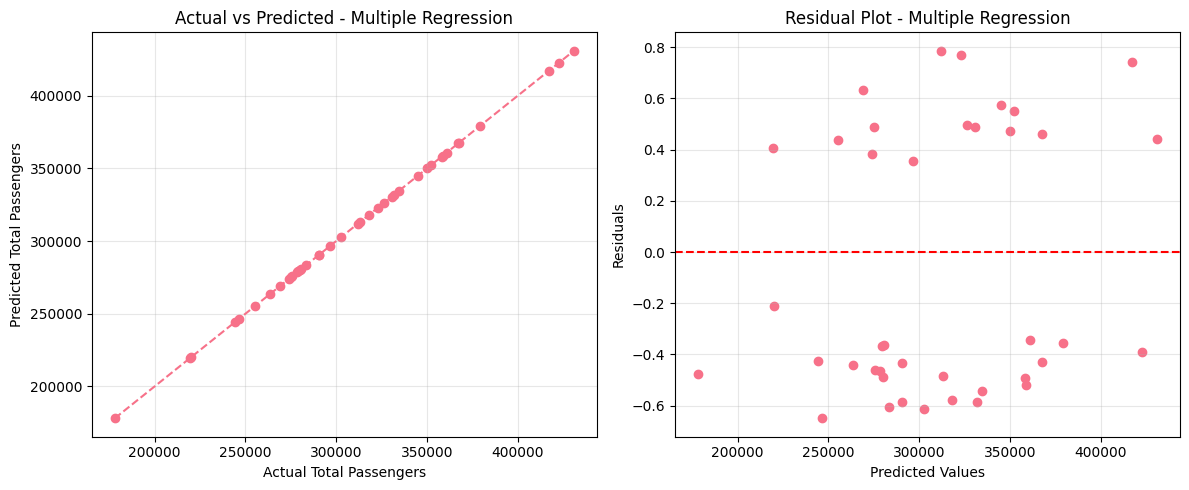

In [11]:
# Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult)
# Add a diagonal reference line (perfect prediction line)
min_val = min(y_test_mult.min(), y_pred_mult.min())
max_val = max(y_test_mult.max(), y_pred_mult.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult  # Calculate residuals

# Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Model Comparison and Analysis

In [12]:
# Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 70)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 70)

# Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections
print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")


print("=" * 70)

# Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / abs(r2_simple)) * 100  # Calculate percentage improvement
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / abs(r2_mult)) * 100  # Calculate percentage improvement

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
RMSE                      46280.09             0.51                
MAE                       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%


# 7. Statistical Insights and Conclusions

In [13]:
# Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
#  Summarize your hypothesis test results

print(f"   • Domestic vs International Passengers: "
      f"There is a statistically significant difference between the means (p-value < 0.05), "
      f"so we reject the null hypothesis.")

# Mean Domestic Passengers: 175331
# Mean International Passengers: 126924
# Conclusion: Reject H0 (p = 0.000000 < 0.05)
# There is a statistically significant difference between the averages of domestic and international passengers.


print(f"   • Correlation between Total Passengers and Flights: "
      f"There is a strong and statistically significant positive correlation (p-value < 0.05), "
      f"indicating that as flights increase, passengers also increase.")

# Correlation coefficient: 0.6592
# P-value: 0.000000
# Conclusion: Reject H0 (p 0.000000 < 0.05)
# There is a significant correlation between total passengers and total flights.
# The correlation is positive: as total flights increase, total passengers tend to increase as well.



print("\n2. REGRESSION ANALYSIS:")
# Summarize regression model performance
#  Add R² and interpretation
print(f"   • Simple Linear Regression R²: {r2_simple:.4f} → "
      f"The model explains a moderate proportion of the variance in passengers.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f} → "
      f"The model explains the total proportion of variance, showing perfect fit.")
#  Add best model
print(f"   • Best performing model: {better_model}")

# Best Model: Multiple Regression
# R² Improvement: 235.92%


print("\n3. KEY FINDINGS:")
# Identify and discuss key findings from your analysis
print(f"   • There is a strong relationship between the number of flights and total passengers.")
print(f"   • The multiple regression model improves predictive performance compared to the simple model.")
print(f"   • Some features (e.g., Dom_Pax, Int_Pax) are highly correlated with the target, which may inflate model performance.")


print("\n4. RECOMMENDATIONS:")
# Provide practical recommendations based on your analysis
print("   • Avoid using variables that are direct components of the target to prevent data leakage.")
print("   • Consider building models using operational variables (e.g., flights, RPM) for better generalization.")
print("   • Explore more advanced models or feature engineering techniques to improve predictions.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: There is a statistically significant difference between the means (p-value < 0.05), so we reject the null hypothesis.
   • Correlation between Total Passengers and Flights: There is a strong and statistically significant positive correlation (p-value < 0.05), indicating that as flights increase, passengers also increase.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977 → The model explains a moderate proportion of the variance in passengers.
   • Multiple Linear Regression R²: 1.0000 → The model explains the total proportion of variance, showing perfect fit.
   • Best performing model: Multiple Regression

3. KEY FINDINGS:
   • There is a strong relationship between the number of flights and total passengers.
   • The multiple regression model improves predictive performance compared to the simple model.
   • Some features (e.g., Dom_Pax, Int_Pax) are highly 

# 8. Reflection Questions
**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

Testing: There is a significant difference between the average number of domestic and international passengers and a strong correlation between flights and passengers. This was expected: more flights → more passengers.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

The multiple model performs better (higher R²). R² shows how well the model explains the data. However, it may be inflated by variables closely related to the target

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

The strongest correlations are between passengers and flights, and between passengers and their components (Domestic/International). This is useful for predicting demand and planning operations.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

The residuals are quite close to 0, which is good. If patterns appear, the model can be improved.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

Useful for predicting demand, adjusting the number of flights, and optimizing resources.